In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import os

In [10]:
base_path = os.getcwd()
print (base_path)
type = "walking_1"
path = os.path.join (base_path, "cleaned_features", f"cleaned_features_{type}.csv")

c:\Users\OliBr\OneDrive\Oliver\ZHAW\8. Semester\geomarketing\geo_marketing_amenity_rent


Read the CSV file into a DataFrame

In [11]:
df = pd.read_csv(path)
print("Initial DataFrame shape:", df.shape)
print("Columns:", df.columns.tolist())

Initial DataFrame shape: (520, 38)
Columns: ['address', 'price', 'lat', 'lon', 'property_id', 'rooms', 'area', 'cafe_count', 'cafe_present', 'restaurant_count', 'restaurant_present', 'bar_count', 'bar_present', 'pub_count', 'pub_present', 'fast_food_count', 'fast_food_present', 'school_count', 'school_present', 'university_count', 'university_present', 'library_count', 'library_present', 'hospital_count', 'hospital_present', 'clinic_count', 'clinic_present', 'pharmacy_count', 'pharmacy_present', 'bank_count', 'bank_present', 'atm_count', 'atm_present', 'bus_station_count', 'bus_station_present', 'parking_count', 'parking_present', 'total_amenities']


# Exploratory Data Analysis (EDA)

a) Summary statistics for the numeric features

In [12]:
print("\n--- Summary Statistics ---")
print(df.describe())


--- Summary Statistics ---
             price         lat         lon   property_id       rooms  \
count   520.000000  520.000000  520.000000  5.200000e+02  520.000000   
mean   3587.269231   47.158896    8.153284  3.998119e+09    4.766346   
std    1615.640750    0.445021    0.786776  6.187506e+07    1.172387   
min    1440.000000   45.947820    6.010496  3.003296e+09    2.500000   
25%    2460.000000   47.031263    7.591083  4.001943e+09    4.000000   
50%    3300.000000   47.352663    8.455714  4.002018e+09    4.500000   
75%    4340.000000   47.458394    8.703874  4.002055e+09    5.500000   
max    9100.000000   47.715924   10.287281  4.002082e+09    8.500000   

             area  cafe_count  cafe_present  restaurant_count  \
count  520.000000  520.000000    520.000000        520.000000   
mean   135.196154    0.540385      0.296154          1.969231   
std     62.790473    1.135478      0.456999          3.143795   
min     33.000000    0.000000      0.000000          0.000000  

b) Check for missing values

In [13]:
print("\n--- Missing Values per Column ---")
print(df.isnull().sum())


--- Missing Values per Column ---
address                0
price                  0
lat                    0
lon                    0
property_id            0
rooms                  0
area                   0
cafe_count             0
cafe_present           0
restaurant_count       0
restaurant_present     0
bar_count              0
bar_present            0
pub_count              0
pub_present            0
fast_food_count        0
fast_food_present      0
school_count           0
school_present         0
university_count       0
university_present     0
library_count          0
library_present        0
hospital_count         0
hospital_present       0
clinic_count           0
clinic_present         0
pharmacy_count         0
pharmacy_present       0
bank_count             0
bank_present           0
atm_count              0
atm_present            0
bus_station_count      0
bus_station_present    0
parking_count          0
parking_present        0
total_amenities        0
dtype: int64


c) Distribution plots

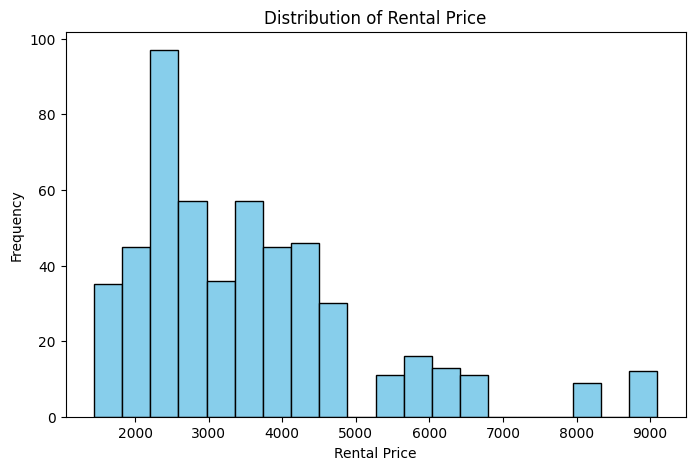

In [14]:
# Rental Price Distribution
plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=20, color="skyblue", edgecolor="black")
plt.xlabel("Rental Price")
plt.ylabel("Frequency")
plt.title("Distribution of Rental Price")
plt.show()

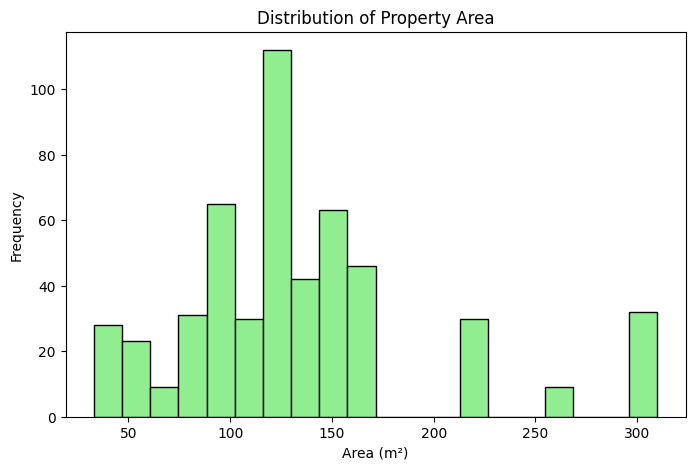

In [15]:
# Area Distribution
plt.figure(figsize=(8, 5))
plt.hist(df["area"].dropna(), bins=20, color="lightgreen", edgecolor="black")
plt.xlabel("Area (m²)")
plt.ylabel("Frequency")
plt.title("Distribution of Property Area")
plt.show()

d) Correlation Matrix


--- Correlation Matrix ---
                      price      area  cafe_count  restaurant_count  \
price              1.000000  0.726467   -0.034347         -0.058997   
area               0.726467  1.000000   -0.028622         -0.045562   
cafe_count        -0.034347 -0.028622    1.000000          0.611896   
restaurant_count  -0.058997 -0.045562    0.611896          1.000000   
bar_count         -0.071152 -0.031630    0.419993          0.682418   
pub_count         -0.010450 -0.004375    0.374272          0.540280   
fast_food_count   -0.046879 -0.084465    0.547996          0.698763   
school_count      -0.012819 -0.037305    0.113821          0.150977   
university_count  -0.061538 -0.054479    0.008480          0.008831   
library_count     -0.077989 -0.007008    0.112786          0.113726   
hospital_count          NaN       NaN         NaN               NaN   
clinic_count      -0.036729 -0.048360    0.176161          0.190650   
pharmacy_count    -0.058840  0.021954    0.366328

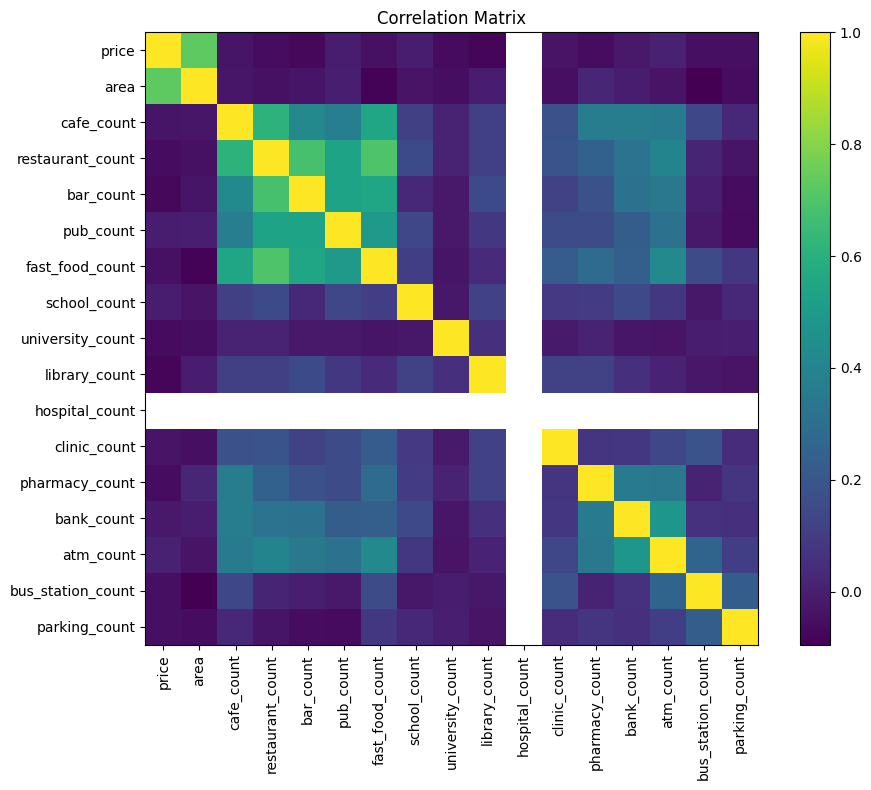

In [16]:
#We'll include price, area, and amenity count columns
allowed_amenities = [
    "cafe", "restaurant", "bar", "pub", "fast_food",
    "school", "university", "library", "hospital",
    "clinic", "pharmacy", "bank", "atm", "bus_station", "parking"
]
# rooms are excluded due to multicollinearity
cols_for_corr = ["price", "area"]
for amenity in allowed_amenities:
    col_name = f"{amenity}_count"
    if col_name in df.columns:
        cols_for_corr.append(col_name)

corr_matrix = df[cols_for_corr].corr()
print("\n--- Correlation Matrix ---")
print(corr_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="viridis", interpolation="nearest")
plt.title("Correlation Matrix")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.tight_layout()
plt.show()

# Further feature engineering

Correlation matrix, when creating less categories, by combining counts

In [17]:
# Get sum of specific columns for each row
df = pd.read_csv(path)
def sum_column(df, columns, sum_name, drop = False):
    df[sum_name] = df[columns].sum(axis=1)
    if drop:
        df = df.drop(columns, axis=1)
    return df
columns = ['cafe_count', 'restaurant_count', 'bar_count', 'pub_count', 'fast_food_count']
df = sum_column(df, columns, "food_beverage_count")

columns = ['school_count', 'university_count', 'library_count']
df = sum_column(df, columns, "education_count")

columns = ['hospital_count', 'clinic_count', 'pharmacy_count']
df = sum_column(df, columns, "healthcare_count")

columns = ['bank_count', 'atm_count']
df = sum_column(df, columns, "financial_services_count")

columns = ['bus_station_count', 'parking_count']
df = sum_column(df, columns, "transportation_count")

df.head()

,address,price,lat,lon,property_id,rooms,area,cafe_count,cafe_present,restaurant_count,...,bus_station_count,bus_station_present,parking_count,parking_present,total_amenities,food_beverage_count,education_count,healthcare_count,financial_services_count,transportation_count
0,"Erlenmattstr. 75, 4058 Basel",2880,47.570509,7.603174,4002039809,4.5,115.0,0,0,1,...,0,0,0,0,2,1,0,1,0,0
1,"Fahrnstrasse 25, 9402 Mörschwil",2880,47.463967,9.432168,4002080979,4.5,115.0,0,0,0,...,0,0,1,1,1,0,0,0,0,1
2,"Volkmarstrasse 15, 8006 Zürich",2880,47.385328,8.543725,4002058756,4.5,115.0,0,0,1,...,0,0,0,0,1,1,0,0,0,0
3,"Niklaus Konrad-Strasse 4, 4500 Solothurn",2880,47.204514,7.539104,4002053936,4.5,115.0,2,1,13,...,0,0,1,1,25,20,1,1,2,1
4,"Via Sasso Corbaro 23, 6593 Cadenazzo",2880,46.151301,8.944420,4001668530,4.5,115.0,0,0,1,...,0,0,0,0,5,2,1,1,1,0



--- Correlation Matrix ---
                             price      area  food_beverage_count  \
price                     1.000000  0.726467            -0.062108   
area                      0.726467  1.000000            -0.052337   
food_beverage_count      -0.062108 -0.052337             1.000000   
education_count          -0.060637 -0.039232             0.172285   
financial_services_count -0.006532 -0.029404             0.476046   
healthcare_count         -0.067181 -0.002374             0.353415   
parking_count            -0.051072 -0.058535            -0.012674   

                          education_count  financial_services_count  \
price                           -0.060637                 -0.006532   
area                            -0.039232                 -0.029404   
food_beverage_count              0.172285                  0.476046   
education_count                  1.000000                  0.118100   
financial_services_count         0.118100                  1.000

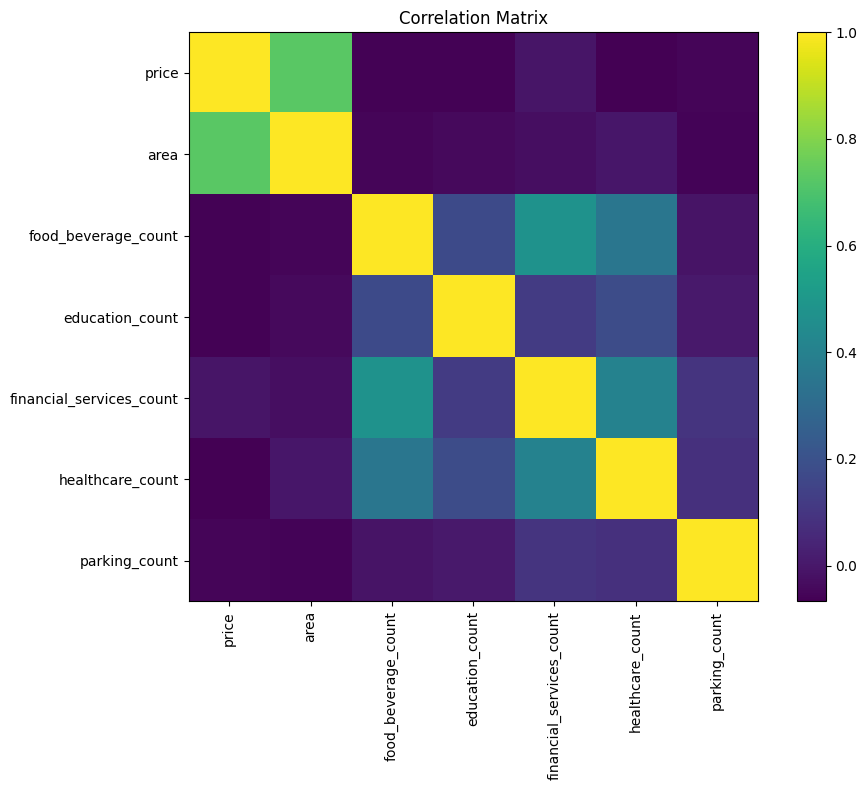

In [18]:
#We'll include price, area, and amenity count columns
allowed_amenities = [
    "food_beverage", "education", "financial_services", "healthcare", "parking"
]
# rooms are excluded due to multicollinearity
cols_for_corr = ["price", "area"]
for amenity in allowed_amenities:
    col_name = f"{amenity}_count"
    if col_name in df.columns:
        cols_for_corr.append(col_name)

corr_matrix = df[cols_for_corr].corr()
print("\n--- Correlation Matrix ---")
print(corr_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="viridis", interpolation="nearest")
plt.title("Correlation Matrix")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.tight_layout()
plt.show()

Correlation based on precence/abscence of feature


--- Correlation Matrix ---
                        price      area  cafe_present  restaurant_present  \
price                1.000000  0.726467     -0.024529            0.010233   
area                 0.726467  1.000000      0.024495            0.038445   
cafe_present        -0.024529  0.024495      1.000000            0.181690   
restaurant_present   0.010233  0.038445      0.181690            1.000000   
bar_present         -0.111464 -0.072443      0.223307            0.213062   
pub_present          0.011247  0.011833      0.247110            0.224231   
fast_food_present   -0.027153 -0.047458      0.295523            0.174353   
school_present      -0.001255 -0.025941      0.144817            0.027295   
university_present  -0.061538 -0.054479      0.006203            0.051243   
library_present     -0.070093 -0.002372      0.059899            0.050383   
hospital_present          NaN       NaN           NaN                 NaN   
clinic_present      -0.025469 -0.046010      0.1

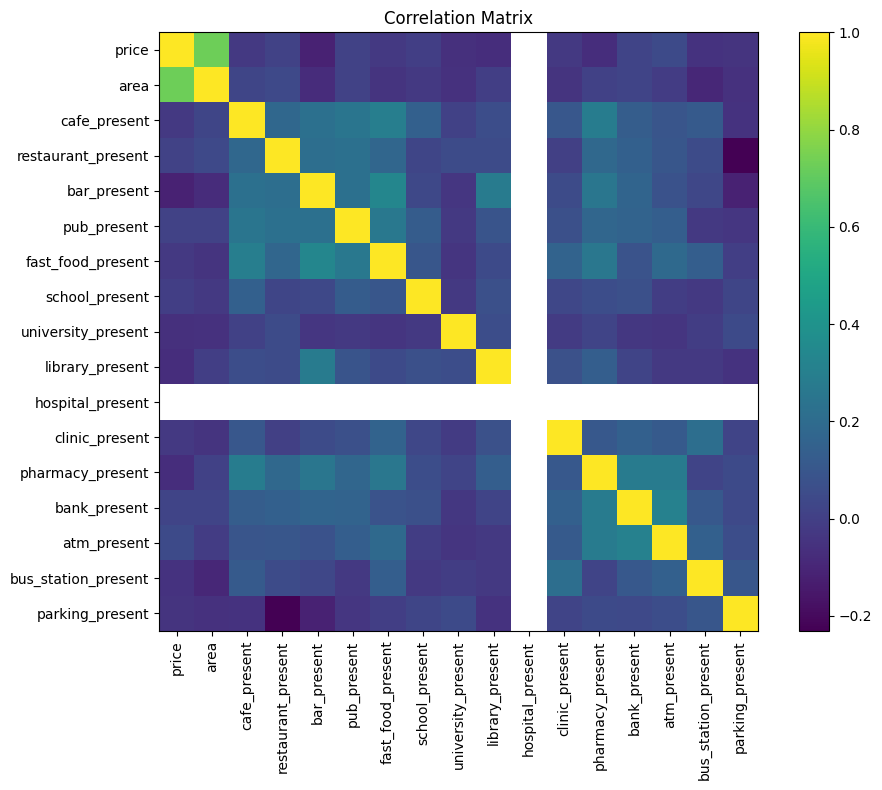

In [ ]:
#We'll include price, area, and amenity count columns
allowed_amenities = [
    "cafe", "restaurant", "bar", "pub", "fast_food",
    "school", "university", "library", "hospital",
    "clinic", "pharmacy", "bank", "atm", "bus_station", "parking"
]
# rooms are excluded due to multicollinearity
cols_for_corr = ["price", "area"]
for amenity in allowed_amenities:
    col_name = f"{amenity}_present"
    if col_name in df.columns:
        cols_for_corr.append(col_name)

numeric_cols = cols_for_corr.select_dtypes(include=[np.number]).columns
cols_for_corr[numeric_cols] = cols_for_corr[numeric_cols].fillna(0)

corr_matrix = df[cols_for_corr].corr()
print("\n--- Correlation Matrix ---")
print(corr_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="viridis", interpolation="nearest")
plt.title("Correlation Matrix")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.tight_layout()
plt.show()

Binary features seem to modify correlations visibly, but correlation is still low. Let's combine feature categories again


--- Correlation Matrix ---
                               price      area  food_beverage_present  \
price                       1.000000  0.726467               0.023396   
area                        0.726467  1.000000               0.066025   
food_beverage_present       0.023396  0.066025               1.000000   
education_present          -0.047597 -0.024705               0.004349   
healthcare_present         -0.071669 -0.000063               0.161462   
financial_services_present  0.051359  0.035158               0.101138   
transportation_present     -0.043331 -0.056582              -0.325880   

                            education_present  healthcare_present  \
price                               -0.047597           -0.071669   
area                                -0.024705           -0.000063   
food_beverage_present                0.004349            0.161462   
education_present                    1.000000            0.138072   
healthcare_present                   0.138

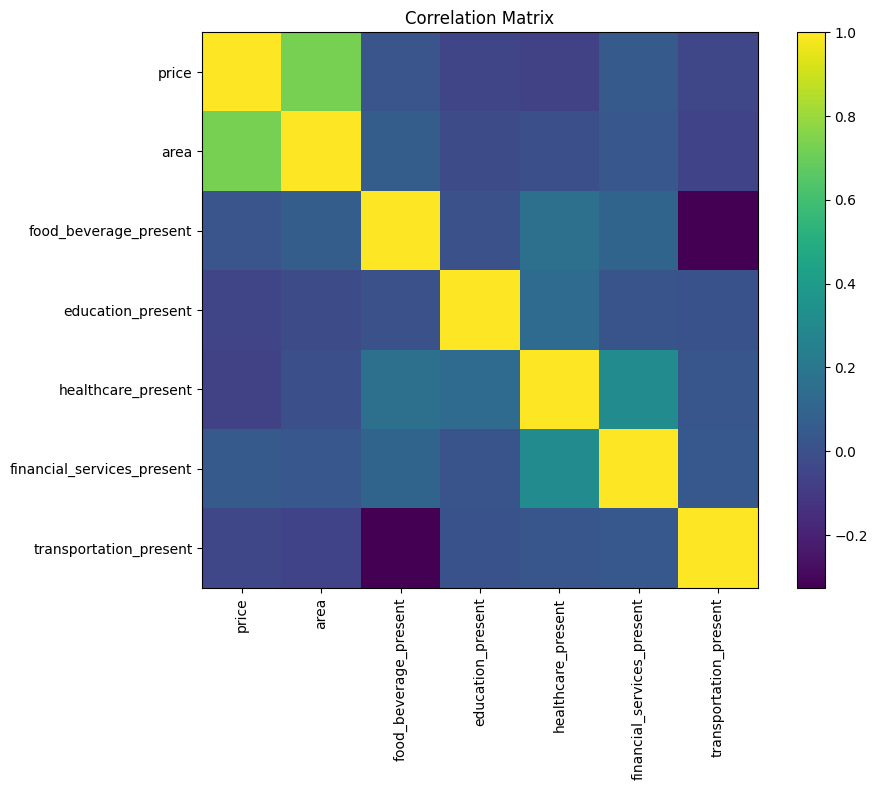

In [20]:
# Get sum of specific columns for each row
type = "walking_1"
df = pd.read_csv(f"cleaned_features/cleaned_features_{type}.csv")
def amenity_present(df, columns, present_name, drop = False):
    df[present_name] = df[columns].sum(axis=1) >= 1
    df[present_name] = df[present_name].astype(int)
    df = df.dropna(subset=[present_name]).copy()
    #print(df.where(df[columns] == 1, other = 0, axis=1))
    if drop:
        df = df.drop(columns, axis=1)
    return df
columns = ['cafe_present', 'bar_present', 'restaurant_present', 'pub_present', 'fast_food_present']
df = amenity_present(df, columns, "food_beverage_present")
""" print(df['restaurant_present'].sum())
for restaurant in df['restaurant_present']:
    if restaurant != 1:
        print(restaurant, "here") """

columns = ['school_present', 'university_present', 'library_present']
df = amenity_present(df, columns, "education_present")

columns = ['hospital_present', 'clinic_present', 'pharmacy_present']
df = amenity_present(df, columns, "healthcare_present")

columns = ['bank_present', 'atm_present']
df = amenity_present(df, columns, "financial_services_present")

columns = ['bus_station_present', 'parking_present']
df = amenity_present(df, columns, "transportation_present")

df.head()
#We'll include price, area, and amenity count columns
allowed_amenities = [
    "food_beverage", "education", "healthcare", "financial_services", "transportation"
]
# rooms are excluded due to multicollinearity
cols_for_corr = ["price", "area"]
for amenity in allowed_amenities:
    col_name = f"{amenity}_present"
    if col_name in df.columns:
        cols_for_corr.append(col_name)
corr_matrix = df[cols_for_corr].corr()
print("\n--- Correlation Matrix ---")
print(corr_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="viridis", interpolation="nearest")
plt.title("Correlation Matrix")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.tight_layout()
plt.show()

# Remove Outliers & Prepare Data for Modeling

In [21]:
# Remove rows with missing critical values
model_df = df.dropna(subset=["price", "area"]).copy()

# Remove outliers:
#   - Rental price above 9000
#   - Area above 300 m²
initial_rows = model_df.shape[0]
model_df = model_df[(model_df["price"] <= 9000) & (model_df["area"] <= 300)]
removed_rows = initial_rows - model_df.shape[0]
print(f"\nRemoved {removed_rows} rows as outliers based on rental price and area criteria.")


Removed 12 rows as outliers based on rental price and area criteria.


In [22]:
# Drop non-modeling columns if not needed (e.g., address, lat, lon, property_id, area)
allowed = ['price','area','cafe_present', 'bar_present', 'restaurant_present', 'pub_present', 'fast_food_present']

model_df = model_df[allowed]
#model_df.drop(columns=[col for col in cols_to_drop if col in model_df.columns], inplace=True)

# Fill any remaining missing numeric values with 0 (or consider other imputation)
numeric_cols = model_df.select_dtypes(include=[np.number]).columns
model_df[numeric_cols] = model_df[numeric_cols].fillna(0)

print("\n--- Modeling Data Sample ---")
print(model_df.head())
print("Final modeling data shape:", model_df.shape)


--- Modeling Data Sample ---
   price   area  cafe_present  bar_present  restaurant_present  pub_present  \
0   2880  115.0             0            0                   1            0   
1   2880  115.0             0            0                   0            0   
2   2880  115.0             0            0                   1            0   
3   2880  115.0             1            0                   1            1   
4   2880  115.0             0            0                   1            1   

   fast_food_present  
0                  0  
1                  0  
2                  0  
3                  1  
4                  0  
Final modeling data shape: (508, 7)


In [23]:
# Save the modeling data to a CSV file for later use in modeling
modeling_output_file = f"modeling/modeling_{type}.csv"
model_df.to_csv(modeling_output_file, index=False)
print(f"Modeling data saved to '{modeling_output_file}'")

Modeling data saved to 'modeling/modeling_walking_1.csv'
